# Fine-tuning Pre-trained Model for Perturbation Prediction

Versión adaptada del full fine-tuning original pero cambiando a un **``fine-tuning parcial``**.

* **Congelamos** los embeddings previos al encoder.
* **Congelamos** las 6 últimas capas del encoder.

De esta manera reducimos el sobreajuste y prevenimos el olvido de las partes más genéricas de la biología celular del modelo. Además, reducimos el coste computacional al tener que entrenar menos parámetros.

## Librerías

In [ ]:
import json
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:64"
import sys
import time
import copy
from pathlib import Path
from typing import Iterable, List, Tuple, Dict, Union, Optional
import warnings

import torch
import gc
import numpy as np
import matplotlib
from torch import nn
from torch.nn import functional as F
from torchtext.vocab import Vocab
from torchtext._torchtext import (
    Vocab as VocabPybind,
)
from torch_geometric.loader import DataLoader
from gears import PertData, GEARS
from gears.inference import compute_metrics, deeper_analysis, non_dropout_analysis
from gears.utils import create_cell_graph_dataset_for_prediction

sys.path.insert(0, "../")

import scgpt as scg
from scgpt.model import TransformerGenerator
from scgpt.loss import (
    masked_mse_loss,
    criterion_neg_log_bernoulli,
    masked_relative_error,
)
from scgpt.tokenizer import tokenize_batch, pad_batch, tokenize_and_pad_batch
from scgpt.tokenizer.gene_tokenizer import GeneVocab
from scgpt.utils import set_seed, map_raw_id_to_vocab_id, compute_perturbation_metrics

import torch.distributed as dist
from torch.nn.parallel import DataParallel as DP

matplotlib.rcParams["savefig.transparent"] = False
warnings.filterwarnings("ignore")

set_seed(42)

gc.collect()
torch.cuda.empty_cache()

c:\Users\loics\Desktop\Universidad\TFM\TFM\ServerTFM\scgpt_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Disabling PyTorch because PyTorch >= 2.4 is required but found 2.1.0+cu121
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


 ## Training Settings

### Configuración de los hiperparámetros y del dataset a utilizar.

In [3]:
# settings for data prcocessing
pad_token = "<pad>"
special_tokens = [pad_token, "<cls>", "<eoc>"]
pad_value = 0  # for padding values
pert_pad_id = 0
include_zero_gene = "all"
max_seq_len = 512   # Era 1536

# settings for training
MLM = True  # whether to use masked language modeling, currently it is always on.
CLS = False  # celltype classification objective
CCE = False  # Contrastive cell embedding objective
MVC = False  # Masked value prediction for cell embedding
ECS = False  # Elastic cell similarity objective
amp = True
load_model = "./save/scGPT_human"
load_param_prefixs = [
    "encoder",
    "value_encoder",
    "transformer_encoder",
]

# settings for optimizer
lr = 5e-5              # Bajamos el LR 1e-4 a 5e-5
weight_decay = 1e-4    # Parámetro de regularización L2
batch_size = 24        
eval_batch_size = 24
epochs = 15            # Antes era 15
schedule_interval = 1
early_stop = 10

# settings for the model
embsize = 512  # embedding dimension
d_hid = 512  # dimension of the feedforward network model in nn.TransformerEncoder
nlayers = 12  # number of nn.TransformerEncoderLayer in nn.TransformerEncoder
nhead = 8  # number of heads in nn.MultiheadAttention
n_layers_cls = 3
dropout = 0.1  #Subimos a 0.1 (antes 0) para regularizar encoder/decoder
use_fast_transformer = False

# logging
log_interval = 300

# dataset and evaluation choices
data_name = "adamson"
split = "simulation"
if data_name == "norman":
    perts_to_plot = ["SAMD1+ZBTB1"]
elif data_name == "adamson":
    perts_to_plot = ["KCTD16+ctrl"]         #KCTD16+ctrl no se puede plotear

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
save_dir = Path(f"./save/dev_perturb_{data_name}-{time.strftime('%b%d-%H-%M')}/")
save_dir.mkdir(parents=True, exist_ok=True)
print(f"saving to {save_dir}")

logger = scg.logger
scg.utils.add_file_handler(logger, save_dir / "run.log")
# log running date and current git commit
logger.info(f"Running on {time.strftime('%Y-%m-%d %H:%M:%S')}")

saving to save\dev_perturb_adamson-May27-19-28
scGPT - INFO - Running on 2026-05-27 19:28:53


Creación de un directorio donde vamos a ir registrando la salida del modelo durante los diferentes batches y épocas del entrenamiento.

In [5]:
pert_data = PertData("./data")
pert_data.load(data_name=data_name)
pert_data.prepare_split(split=split, seed=1)
pert_data.get_dataloader(batch_size=batch_size, test_batch_size=eval_batch_size)

Found local copy...
Found local copy...
Found local copy...
These perturbations are not in the GO graph and their perturbation can thus not be predicted
['SRPR+ctrl' 'SLMO2+ctrl' 'TIMM23+ctrl' 'AMIGO3+ctrl' 'KCTD16+ctrl']
Local copy of pyg dataset is detected. Loading...
Done!
Local copy of split is detected. Loading...
Simulation split test composition:
combo_seen0:0
combo_seen1:0
combo_seen2:0
unseen_single:21
Done!
Creating dataloaders....
Done!


here1


Nos descargamos el dataset mediante el uso de la librería de GEARS, creando toda la configuración de los ficheros de manera automática (Sirve para el dataset de Adamson y Replogle).

In [6]:
if load_model is not None:
    try:
        model_dir = Path(load_model)
        model_config_file = model_dir / "args.json"
        model_file = model_dir / "best_model.pt"
        vocab_file = model_dir / "vocab.json"

        # Verificar que el archivo vocab.json no esté vacío
        if vocab_file.exists() and vocab_file.stat().st_size > 0:
            vocab = GeneVocab.from_file(vocab_file)
            for s in special_tokens:
                if s not in vocab:
                    vocab.append_token(s)

            pert_data.adata.var["id_in_vocab"] = [
                1 if gene in vocab else -1 for gene in pert_data.adata.var["gene_name"]
            ]
            gene_ids_in_vocab = np.array(pert_data.adata.var["id_in_vocab"])
            logger.info(
                f"match {np.sum(gene_ids_in_vocab >= 0)}/{len(gene_ids_in_vocab)} genes "
                f"in vocabulary of size {len(vocab)}."
            )
            genes = pert_data.adata.var["gene_name"].tolist()

            # model
            with open(model_config_file, "r") as f:
                model_configs = json.load(f)
            logger.info(
                f"Resume model from {model_file}, the model args will override the "
                f"config {model_config_file}."
            )
            embsize = model_configs["embsize"]
            nhead = model_configs["nheads"]
            d_hid = model_configs["d_hid"]
            nlayers = model_configs["nlayers"]
            n_layers_cls = model_configs["n_layers_cls"]
        else:
            logger.warning("vocab.json is empty or corrupted. Using data genes instead.")
            genes = pert_data.adata.var["gene_name"].tolist()
            vocab = Vocab(
                VocabPybind(genes + special_tokens, None)
            )
    except Exception as e:
        logger.warning(f"Failed to load pretrained model: {e}. Using data genes instead.")
        genes = pert_data.adata.var["gene_name"].tolist()
        vocab = Vocab(
            VocabPybind(genes + special_tokens, None)
        )
else:
    genes = pert_data.adata.var["gene_name"].tolist()
    vocab = Vocab(
        VocabPybind(genes + special_tokens, None)
    )  # bidirectional lookup [gene <-> int]
vocab.set_default_index(vocab["<pad>"])
gene_ids = np.array(
    [vocab[gene] if gene in vocab else vocab["<pad>"] for gene in genes], dtype=int
)
n_genes = len(genes)

scGPT - INFO - match 4399/5060 genes in vocabulary of size 60697.
scGPT - INFO - Resume model from save\scGPT_human\best_model.pt, the model args will override the config save\scGPT_human\args.json.


Cargamos el modelo orginal de scGPT llamado best_model.py junto con su fichero de hiperparámetros y un fichero de vocabulario donde se encuentran todos los genes que entiende el modelo.

 # Create and train scGpt

In [7]:
ntokens = len(vocab)
model = TransformerGenerator(
    ntokens,
    embsize,
    nhead,
    d_hid,
    nlayers,
    nlayers_cls=n_layers_cls,
    n_cls=1,
    vocab=vocab,
    dropout=dropout,
    pad_token=pad_token,
    pad_value=pad_value,
    pert_pad_id=pert_pad_id,
    use_fast_transformer=use_fast_transformer,
)

if load_model is not None:
    model_file = Path(load_model) / "best_model.pt"
    pretrained_dict = torch.load(model_file, map_location=device)
    model_dict = model.state_dict()

    # Filtrar parámetros por prefijo y por coincidencia de forma (shape)
    # Esto evita el RuntimeError por claves inesperadas o tamaños distintos
    pretrained_dict = {
        k: v for k, v in pretrained_dict.items()
        if k in model_dict and v.shape == model_dict[k].shape
    }
    
    for k, v in pretrained_dict.items():
        logger.info(f"Loading params {k} with shape {v.shape}")
        
    model_dict.update(pretrained_dict)
    model.load_state_dict(model_dict, strict=False) # strict=False permite ignorar las capas Wqkv problemáticas
    logger.info("Modelo cargado parcialmente (ignoring incompatible layers)")

# 1. Congelar los embeddings de los genes y de los valores de expresión
for param in model.encoder.parameters():
    param.requires_grad = False
for param in model.value_encoder.parameters():
    param.requires_grad = False

# 2. Congelar la SEGUNDA mitad de los bloques del Encoder
# Al usar range(capas_a_congelar, nlayers) con nlayers=12, 
# iteramos desde el índice 6 hasta el 11, congelando la última mitad.
capas_a_congelar = nlayers // 2 
for i in range(capas_a_congelar, nlayers):
    for param in model.transformer_encoder.layers[i].parameters():
        param.requires_grad = False

logger.info(f"Embeddings y los bloques del encoder desde el {capas_a_congelar} al {nlayers-1} han sido congelados.")

# --- CONFIGURACIÓN MULTI-GPU ---
# Primero mover a la CPU/GPU base y luego envolver
model.to(device)

if hasattr(model, "transformer_encoder"):
    model.transformer_encoder.gradient_checkpointing = True

if torch.cuda.device_count() > 1:
    print(f"Detectadas {torch.cuda.device_count()} GPUs. Activando DataParallel.")
    model = nn.DataParallel(model)

scGPT - INFO - Loading params encoder.embedding.weight with shape torch.Size([60697, 512])
scGPT - INFO - Loading params encoder.enc_norm.weight with shape torch.Size([512])
scGPT - INFO - Loading params encoder.enc_norm.bias with shape torch.Size([512])
scGPT - INFO - Loading params value_encoder.linear1.weight with shape torch.Size([512, 1])
scGPT - INFO - Loading params value_encoder.linear1.bias with shape torch.Size([512])
scGPT - INFO - Loading params value_encoder.linear2.weight with shape torch.Size([512, 512])
scGPT - INFO - Loading params value_encoder.linear2.bias with shape torch.Size([512])
scGPT - INFO - Loading params value_encoder.norm.weight with shape torch.Size([512])
scGPT - INFO - Loading params value_encoder.norm.bias with shape torch.Size([512])
scGPT - INFO - Loading params transformer_encoder.layers.0.self_attn.out_proj.weight with shape torch.Size([512, 512])
scGPT - INFO - Loading params transformer_encoder.layers.0.self_attn.out_proj.bias with shape torch.Si

In [8]:
def eval_perturb(
    loader: DataLoader, model: TransformerGenerator, device: torch.device
) -> Dict:
    """
    Ejecuta el modelo en modo inferencia usando el cargador de datos proporcionado.
    """
    model.eval()
    model.to(device)
    pert_cat = []
    pred = []
    truth = []
    pred_de = []
    truth_de = []
    results = {}

    for itr, batch in enumerate(loader):
        batch.to(device)
        pert_cat.extend(batch.pert)

        # --- CORRECCIÓN PARA EL INDEXERROR ---
        # Si x solo tiene una columna (expresión), añadimos una segunda columna
        # de ceros (flags de perturbación) para que scGPT no falle.
        if batch.x.shape[1] == 1:
            # Creamos un tensor de ceros del mismo tamaño que la columna de expresión
            pert_flags_dummy = torch.zeros_like(batch.x)
            # Los concatenamos para tener forma (N_genes * Batch_size, 2)
            batch.x = torch.cat([batch.x, pert_flags_dummy], dim=1)
        # --------------------------------------

        with torch.no_grad():
            # Seleccionamos el modelo interno para evitar conflictos de DataParallel
            model_to_predict = model.module if isinstance(model, torch.nn.DataParallel) else model
            
            # Forzamos una limpieza de cache justo antes de la inferencia pesada
            torch.cuda.empty_cache()
            
            # Ejecutamos la predicción
            # Reducimos eval_batch_size en la configuración a 2 o 4 si esto falla
            p = model_to_predict.pred_perturb(
                batch,
                include_zero_gene=include_zero_gene,
                gene_ids=gene_ids,
                amp=amp # Asegúrate de que amp esté pasado aquí también
            )
            
            t = batch.y
            pred.extend(p.cpu())
            truth.extend(t.cpu())

            # Liberamos p de la GPU inmediatamente tras moverlo a CPU
            del p
            torch.cuda.empty_cache()

    # Convertir resultados a numpy para las métricas
    results["pert_cat"] = np.array(pert_cat)
    pred = torch.stack(pred)
    truth = torch.stack(truth)
    results["pred"] = pred.detach().cpu().numpy().astype(float)
    results["truth"] = truth.detach().cpu().numpy().astype(float)

    # --- CORRECCIÓN PARA EL RUNTIME ERROR ---
    if len(pred_de) > 0:
        pred_de = torch.stack(pred_de)
        truth_de = torch.stack(truth_de)
        results["pred_de"] = pred_de.detach().cpu().numpy().astype(float)
        results["truth_de"] = truth_de.detach().cpu().numpy().astype(float)
    else:
        # Si no se encontraron genes DE en este loader, devolvemos arrays vacíos
        # para evitar que el código siguiente falle
        results["pred_de"] = np.empty((0,))
        results["truth_de"] = np.empty((0,))
    # ----------------------------------------

    return results


Función ``eval_perturb`` que nos pertmite evaluar el modelo con parte de validación del dataset.

In [9]:

criterion = masked_mse_loss
criterion_cls = nn.CrossEntropyLoss()

# MODIFICADO: Añadimos el parámetro weight_decay al optimizador Adam
trainable_params = filter(lambda p: p.requires_grad, model.parameters())
optimizer = torch.optim.Adam(trainable_params, lr=lr, weight_decay=weight_decay)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, schedule_interval, gamma=0.9)
scaler = torch.cuda.amp.GradScaler(enabled=amp)


def train(model: nn.Module, train_loader: torch.utils.data.DataLoader, valid_loader: torch.utils.data.DataLoader, pert_data) -> None:
    """
    Train the model for one epoch.
    """
    model.train()
    total_loss, total_mse = 0.0, 0.0
    start_time = time.time()

    num_batches = len(train_loader)
    for batch, batch_data in enumerate(train_loader):
        batch_size = len(batch_data.y)
        batch_data.to(device)
        x: torch.Tensor = batch_data.x  # (batch_size * n_genes, 2)
        ori_gene_values = x[:, 0].view(batch_size, n_genes)
        if x.shape[1] > 1:
            pert_flags = x[:, 1].long().view(batch_size, n_genes)
        else:
            pert_flags = torch.zeros((batch_size, n_genes), dtype=torch.long, device=device)
        target_gene_values = batch_data.y  # (batch_size, n_genes)

        if include_zero_gene in ["all", "batch-wise"]:
            if include_zero_gene == "all":
                input_gene_ids = torch.arange(n_genes, device=device, dtype=torch.long)
            else:
                input_gene_ids = (
                    ori_gene_values.nonzero()[:, 1].flatten().unique().sort()[0]
                )
            # sample input_gene_id
            if len(input_gene_ids) > max_seq_len:
                input_gene_ids = torch.randperm(len(input_gene_ids), device=device)[
                    :max_seq_len
                ]
            input_values = ori_gene_values[:, input_gene_ids]
            input_pert_flags = pert_flags[:, input_gene_ids]
            target_values = target_gene_values[:, input_gene_ids]

            mapped_input_gene_ids = map_raw_id_to_vocab_id(input_gene_ids, gene_ids)
            mapped_input_gene_ids = mapped_input_gene_ids.repeat(batch_size, 1)

            # src_key_padding_mask = mapped_input_gene_ids.eq(vocab[pad_token])
            src_key_padding_mask = torch.zeros_like(
                input_values, dtype=torch.bool, device=device
            )

        with torch.cuda.amp.autocast(enabled=amp):
            output_dict = model(
                mapped_input_gene_ids,
                input_values,
                input_pert_flags,
                src_key_padding_mask=src_key_padding_mask,
                CLS=CLS,
                CCE=CCE,
                MVC=MVC,
                ECS=ECS,
            )
            output_values = output_dict["mlm_output"]

            masked_positions = torch.ones_like(
                input_values, dtype=torch.bool
            )  # Use all
            loss = loss_mse = criterion(output_values, target_values, masked_positions)

        model.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        with warnings.catch_warnings(record=True) as w:
            warnings.filterwarnings("always")
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0,
                error_if_nonfinite=False if scaler.is_enabled() else True,
            )
            if len(w) > 0:
                logger.warning(
                    f"Found infinite gradient. This may be caused by the gradient "
                    f"scaler. The current scale is {scaler.get_scale()}. This warning "
                    "can be ignored if no longer occurs after autoscaling of the scaler."
                )
        scaler.step(optimizer)
        scaler.update()

        # torch.cuda.empty_cache()

        total_loss += loss.item()
        total_mse += loss_mse.item()
        if batch % log_interval == 0 and batch > 0:
            lr = scheduler.get_last_lr()[0]
            ms_per_batch = (time.time() - start_time) * 1000 / log_interval
            cur_loss = total_loss / log_interval
            cur_mse = total_mse / log_interval
            # ppl = math.exp(cur_loss)
            logger.info(
                f"| epoch {epoch:3d} | {batch:3d}/{num_batches:3d} batches | "
                f"lr {lr:05.4f} | ms/batch {ms_per_batch:5.2f} | "
                f"loss {cur_loss:5.2f} | mse {cur_mse:5.2f} |"
            )
            
            total_loss = 0
            total_mse = 0
            start_time = time.time()


### Función `train`

1. **Inicialización**: Pone el modelo en modo de entrenamiento y reinicia los contadores de pérdida.

2. **Iteración sobre batches**: Para cada lote del dataloader de entrenamiento:
   - Extrae los valores originales de genes y los flags de perturbación
   - Selecciona un subconjunto de genes para la entrada (hasta `max_seq_len`)
   - Mapea los IDs de genes a IDs del vocabulario

3. **Forward pass**: Pasa los datos al modelo

4. **Cálculo de pérdida**: Computa el error MSE entre los valores predichos y los valores objetivo usando la máscara de posiciones.

5. **Backpropagation**: 
   - Calcula gradientes
   - Actualiza los pesos del modelo con el optimizador

6. **Logging**: Cada `log_interval` batches:
   - Imprime las estadísticas de entrenamiento (loss, MSE, learning rate)
   - Evalúa el modelo en validación usando `eval_perturb`
   - Calcula y muestra métricas de perturbación (Pearson, Pearson DE, etc.)

In [10]:
best_val_loss = float("inf")
best_val_corr = 0
best_model = None
patience = 0

for epoch in range(1, epochs + 1):
    epoch_start_time = time.time()
    train_loader = pert_data.dataloader["train_loader"]
    valid_loader = pert_data.dataloader["val_loader"]

    train(
        model,
        train_loader,
        valid_loader,
        pert_data
    )
    torch.cuda.empty_cache()
    gc.collect()
    val_res = eval_perturb(valid_loader, model, device)
    val_metrics = compute_perturbation_metrics(
        val_res, pert_data.adata[pert_data.adata.obs["condition"] == "ctrl"]
    )
    logger.info(f"val_metrics at epoch {epoch}: ")
    logger.info(val_metrics)

    elapsed = time.time() - epoch_start_time
    logger.info(f"| end of epoch {epoch:3d} | time: {elapsed:5.2f}s | ")

    val_score = val_metrics["pearson"]
    if val_score > best_val_corr:
        best_val_corr = val_score
        best_model = copy.deepcopy(model)
        logger.info(f"Best model with score {val_score:5.4f}")
        patience = 0
    else:
        patience += 1
        if patience >= early_stop:
            logger.info(f"Early stop at epoch {epoch}")
            break

    # torch.save(
    #     model.state_dict(),
    #     save_dir / f"model_{epoch}.pt",
    # )

    scheduler.step()


scGPT - INFO - | epoch   1 | 300/2197 batches | lr 0.0001 | ms/batch 263.44 | loss  0.10 | mse  0.10 |
scGPT - INFO - | epoch   1 | 600/2197 batches | lr 0.0001 | ms/batch 272.41 | loss  0.09 | mse  0.09 |
scGPT - INFO - | epoch   1 | 900/2197 batches | lr 0.0001 | ms/batch 278.23 | loss  0.08 | mse  0.08 |
scGPT - INFO - | epoch   1 | 1200/2197 batches | lr 0.0001 | ms/batch 265.20 | loss  0.08 | mse  0.08 |
scGPT - INFO - | epoch   1 | 1500/2197 batches | lr 0.0001 | ms/batch 285.06 | loss  0.08 | mse  0.08 |
scGPT - INFO - | epoch   1 | 1800/2197 batches | lr 0.0001 | ms/batch 271.96 | loss  0.08 | mse  0.08 |
scGPT - INFO - | epoch   1 | 2100/2197 batches | lr 0.0001 | ms/batch 261.81 | loss  0.08 | mse  0.08 |
scGPT - INFO - val_metrics at epoch 1: 
scGPT - INFO - {'pearson': 0.9859874705149302, 'pearson_de': 0.8985167484764199, 'pearson_delta': 0.6042209020782209, 'pearson_de_delta': 0.8877888104284191}
scGPT - INFO - | end of epoch   1 | time: 4217.39s | 
scGPT - INFO - Best mod

Celda donde vamos a entrenar el modelo llamando a la función `train()` e imprime la evolución del modelo durante las épocas con los resultados de las métricas del conjunto de validación con la función `eval_perturb`

In [11]:
torch.save(best_model.state_dict(), save_dir / "best_model.pt")

El modelo al que le hemos aplicado fine-tuning lo guardamos en la carpeta **save_dir** con el nombre de **best_model.pt**

 ## Evaluations

In [12]:
def predict(
    model: TransformerGenerator,
    perturbations: List[List[str]],
    pool_size: int = None,
    batch_size: int = 4,
    include_zero_gene: str = "batch-wise",
) -> Dict:
    """
    Versión Final (v4):
    - Incluye sanitización automática de input (flattening).
    - Soluciona el error de broadcasting (ValueError).
    - Soluciona el error de tipos en join (TypeError).
    """

    # --- 1. SANITIZACIÓN DE ENTRADA (CRÍTICO) ---
    # Detectamos si 'perturbations' tiene un nivel extra de anidamiento.
    # Caso erróneo: [[['A', 'B']]] -> Queremos [['A', 'B']]
    if len(perturbations) > 0 and isinstance(perturbations[0], list) and len(perturbations[0]) > 0:
        if isinstance(perturbations[0][0], list):
            # print("Detectado anidamiento extra en perturbaciones. Corrigiendo...")
            perturbations = [p[0] for p in perturbations]
    # --------------------------------------------

    # 2. Obtener lista de genes
    if hasattr(pert_data, 'gene_names'):
        gene_list = pert_data.gene_names
    else:
        gene_list = pert_data.adata.var.index.tolist()

    # 3. Crear dataset (ahora recibirá la estructura correcta)
    cell_graphs = create_cell_graph_dataset_for_prediction(
        perturbations, 
        pert_data.adata, 
        gene_list,
        device
    )
    
    # 4. Loader
    loader = DataLoader(cell_graphs, batch_size=batch_size, shuffle=False)
    
    model.eval()
    
    res = {}
    
    for batch_data in loader:
        batch_data.to(device)
        
        # Parches de dimensiones para scGPT
        if batch_data.x.dim() == 1:
            batch_data.x = batch_data.x.unsqueeze(1)
        if batch_data.x.shape[1] == 1:
            pert_flags_dummy = torch.zeros_like(batch_data.x)
            batch_data.x = torch.cat([batch_data.x, pert_flags_dummy], dim=1)

        with torch.no_grad():
            torch.cuda.empty_cache()
            
            # DataParallel check
            if isinstance(model, torch.nn.DataParallel):
                pred_gene_values = model.module.pred_perturb(
                    batch_data, include_zero_gene, gene_ids=gene_ids, amp=amp
                )
            else:
                pred_gene_values = model.pred_perturb(
                    batch_data, include_zero_gene, gene_ids=gene_ids, amp=amp
                )
            
            for itr, p in enumerate(batch_data.pert):
                # Sanitización de salida (por si acaso queda algo residual)
                if isinstance(p, list) and len(p) > 0 and isinstance(p[0], list):
                    p = p[0]
                
                pert_key = "_".join(p)
                if pert_key not in res:
                    res[pert_key] = []
                res[pert_key].append(pred_gene_values[itr].detach().cpu())
                
            del pred_gene_values

    # Procesar resultados
    final_res = {}
    for key, values in res.items():
        if len(values) == 0: continue # Skip empty results
        
        values = torch.stack(values)
        if pool_size is not None:
            if values.shape[0] > pool_size:
                idx = torch.randperm(values.shape[0])[:pool_size]
                values = values[idx]
            final_res[key] = values.mean(dim=0).numpy()
        else:
            final_res[key] = values.numpy()
            
    return final_res

### Función `predict`

La función `predict` realiza predicciones sobre perturbaciones genéticas. Sus pasos principales son:

1. **Sanitización de entrada**: 
   - Asegura que el formato sea correcto: `[['gen1', 'gen2'], ...]`

2. **Preparación de datos**:
   - Obtiene la lista de genes desde `pert_data`
   - Crea un dataset de grafos celulares usando `create_cell_graph_dataset_for_prediction`
   - Construye un DataLoader con el tamaño de batch especificado

3. **Inferencia**:
   - Pone el modelo en modo evaluación (`model.eval()`)
   - Para cada batch:
     - Ajusta las dimensiones de los datos
     - Realiza predicciones sin calcular gradientes (`torch.no_grad()`)
     - Llama a `model.pred_perturb()`
     - Agrupa predicciones por clave de perturbación

4. **Procesamiento de resultados**:
   - Apila las predicciones para cada perturbación
   - Si se especifica `pool_size`, muestrea aleatoriamente y promedia
   - Convierte a NumPy y retorna un diccionario con las perturbaciones como claves

In [13]:
def plot_perturbation(
    model: torch.nn.Module, query: str, save_file: str = None, pool_size: int = None
):
    import matplotlib.pyplot as plt
    import numpy as np
    import seaborn as sns

    sns.set_theme(style="ticks", rc={"axes.facecolor": (0, 0, 0, 0)}, font_scale=1.5)

    adata = pert_data.adata
    gene2idx = pert_data.node_map
    gene_raw2id = dict(zip(adata.var.index.values, adata.var.gene_name.values))
    
    # --- MAPEO INTELIGENTE DE NOMBRES ---
    # Creamos diccionarios para traducir entre nombre complejo y simple
    # cond2name: 'AARS+ctrl' -> 'K562(?)_AARS+ctrl_1+1'
    cond2name = dict(adata.obs[["condition", "condition_name"]].values)
    # name2cond: 'K562(?)_AARS+ctrl_1+1' -> 'AARS+ctrl' (Mapeo inverso)
    name2cond = {v: k for k, v in cond2name.items()}
    
    # 1. Resolver la clave para buscar los DATOS (Ground Truth)
    # Preferimos la clave compleja porque es la que usa 'top_non_dropout_de_20'
    if query in adata.uns["top_non_dropout_de_20"]:
        data_key = query
    elif query in cond2name and cond2name[query] in adata.uns["top_non_dropout_de_20"]:
        data_key = cond2name[query]
    else:
        raise KeyError(f"No se encontraron datos para la perturbación: {query}")

    # 2. Resolver el nombre limpio para el MODELO (Predicción)
    # Necesitamos el formato 'GEN+ctrl' para hacer el split correctamente
    if query in name2cond:
        simple_name = name2cond[query] # Transformamos 'K562...AARS...' a 'AARS+ctrl'
    else:
        simple_name = query # Asumimos que ya es simple si no está en el dict

    # ------------------------------------

    # Recuperar genes Top-20 usando la clave de datos (compleja)
    top_20_genes = adata.uns["top_non_dropout_de_20"][data_key]
    de_idx = [gene2idx[gene_raw2id[i]] for i in top_20_genes]
    genes = [gene_raw2id[i] for i in top_20_genes]

    # Recuperar Ground Truth (usando data_key para filtrar obs si es necesario, 
    # aunque normalmente condition_name es único, a veces es mejor filtrar por condition simple)
    # Intentamos filtrar por la condición exacta que coincida con la query
    if "condition_name" in adata.obs:
         truth = adata[adata.obs.condition_name == data_key].X.toarray()[:, de_idx]
    else:
         truth = adata[adata.obs.condition == simple_name].X.toarray()[:, de_idx]

    # Predicción (usando el nombre simple para extraer el gen)
    # Manejo de DataParallel
    model_to_predict = model.module if isinstance(model, torch.nn.DataParallel) else model
    
    gene_target = simple_name.split("+")[0]
    pert_type = simple_name.split("+")[1]
    
    if pert_type == "ctrl":
        pred = predict(model_to_predict, [[gene_target]], pool_size=pool_size)
        pred = pred[gene_target][de_idx]
    else:
        # Caso combinatorial (ej. GEN1+GEN2)
        pred = predict(model_to_predict, [simple_name.split("+")], pool_size=pool_size)
        pred = pred["_".join(simple_name.split("+"))][de_idx]

    ctrl_means = adata[adata.obs["condition"] == "ctrl"].to_df().mean()[de_idx].values

    pred = pred - ctrl_means
    truth = truth - ctrl_means

    fig, ax = plt.subplots(figsize=[16.5, 4.5])
    plt.title(data_key) # Título con el nombre completo
    plt.boxplot(truth, showfliers=False, medianprops=dict(linewidth=0))

    for i in range(pred.shape[0]):
        _ = plt.scatter(i + 1, pred[i], color="red")

    plt.axhline(0, linestyle="dashed", color="green")

    ax.xaxis.set_ticklabels(genes, rotation=90)

    plt.ylabel("Change in Gene Expression over Control", labelpad=10)
    plt.tick_params(axis="x", which="major", pad=5)
    plt.tick_params(axis="y", which="major", pad=5)
    sns.despine()

    if save_file:
        fig.savefig(save_file, bbox_inches="tight", transparent=False)
        print(f"Gráfica guardada en: {save_file}")

    return fig

In [14]:
# Listar todas las perturbaciones válidas que tienen métricas calculadas
valid_keys = list(pert_data.adata.uns["top_non_dropout_de_20"].keys())

print(f"Tienes {len(valid_keys)} perturbaciones válidas.")
print("Las primeras 5 son:", valid_keys[:5])

Tienes 86 perturbaciones válidas.
Las primeras 5 son: ['K562(?)_AARS+ctrl_1+1', 'K562(?)_AMIGO3+ctrl_1+1', 'K562(?)_ARHGAP22+ctrl_1+1', 'K562(?)_ASCC3+ctrl_1+1', 'K562(?)_ATP5B+ctrl_1+1']


Graficando: ['K562(?)_AARS+ctrl_1+1', 'K562(?)_AMIGO3+ctrl_1+1', 'K562(?)_ARHGAP22+ctrl_1+1']
Error graficando K562(?)_AARS+ctrl_1+1: [Errno 22] Invalid argument: 'save\\dev_perturb_adamson-May27-19-28/K562(?)_AARS+ctrl_1+1.png'
Error graficando K562(?)_AMIGO3+ctrl_1+1: operands could not be broadcast together with shapes (5060,) (3,) 
Error graficando K562(?)_ARHGAP22+ctrl_1+1: [Errno 22] Invalid argument: 'save\\dev_perturb_adamson-May27-19-28/K562(?)_ARHGAP22+ctrl_1+1.png'


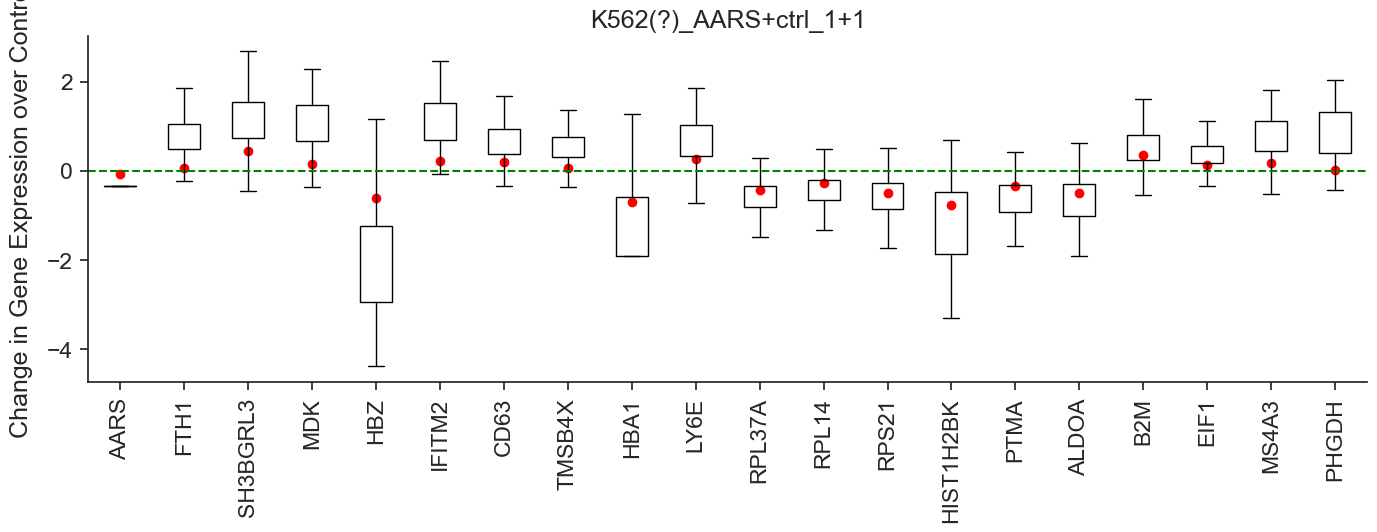

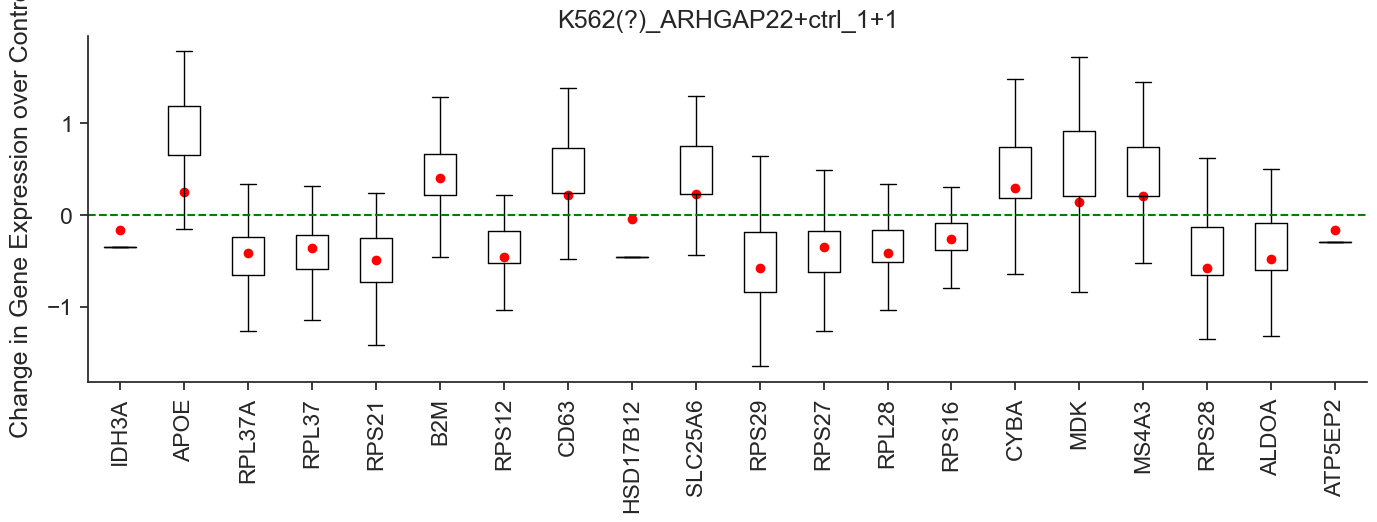

In [15]:
# Obtenemos la lista de perturbaciones válidas (las complejas)
valid_perts = list(pert_data.adata.uns["top_non_dropout_de_20"].keys())

# Seleccionamos las primeras 3 para probar
perts_to_plot = valid_perts[:3] 

print(f"Graficando: {perts_to_plot}")
for p in perts_to_plot:
    try:
        plot_perturbation(
            best_model, 
            p, 
            pool_size=300, 
            save_file=f"{save_dir}/{p}.png"
        )
    except Exception as e:
        print(f"Error graficando {p}: {e}")

La función `plot_perturbation` nos muestra para cada perturbación, una serie de boxplots para los 20 genes más diferencialmente más expresados tras la perturbación (DEGs).

El boxplot muestra el cambio real de expresión de dicho gen tras la perturbación y el punto rojo muestra el cambio de expresión predicho por el modelo.

De esta manera, evaluamos lo bien que predice scGPT el cambio de expresión. Si el punto cae dentro del boxplot significa que ha conseguido predecir con bastante exactitud el cambio de expresión.

In [16]:
import numpy as np
from scipy.stats import pearsonr
import logging

logger = logging.getLogger(__name__)

def deeper_analysis(adata, test_res, de_column_prefix='top_non_dropout_de_20', most_variable_genes=False):
    """
    Versión blindada de deeper_analysis.
    Maneja arrays vacíos, tipos objeto y evita errores de numpy/scipy.
    """
    results = {}
    
    # 1. Obtener media del control (si existe)
    if 'ctrl' in adata.obs['condition'].values:
        try:
            ctrl_mean = adata[adata.obs['condition'] == 'ctrl'].X.toarray().mean(0)
        except:
            ctrl_mean = np.zeros(adata.shape[1])
    else:
        ctrl_mean = np.zeros(adata.shape[1])

    unique_perts = np.unique(test_res['pert_cat'])
    
    for pert in unique_perts:
        if pert == 'ctrl':
            continue
            
        # Índices de esta perturbación
        pert_idx = np.where(test_res['pert_cat'] == pert)[0]
        if len(pert_idx) == 0: continue
        
        results[pert] = {}
        
        # --- BLOQUE DE SEGURIDAD ---
        try:
            # Intentamos apilar los arrays. Si hay mezclas de vacíos y llenos, esto suele fallar o dar object
            # Filtramos primero los arrays vacíos para evitar problemas
            valid_pred = [x for x in test_res['pred_de'][pert_idx] if x.size > 0]
            valid_truth = [x for x in test_res['truth_de'][pert_idx] if x.size > 0]
            
            if len(valid_pred) == 0 or len(valid_truth) == 0:
                # Si no hay datos válidos para esta perturbación, rellenamos con 0 y saltamos
                results[pert]['pearson_delta_de'] = 0
                results[pert]['pearson_delta'] = 0
                continue
                
            pred_de_matrix = np.vstack(valid_pred).astype(float)
            truth_de_matrix = np.vstack(valid_truth).astype(float)
            
        except Exception as e:
            # Si falla la conversión (ej. formas irregulares), saltamos esta perturbación
            # logger.warning(f"Saltando perturbación {pert} por error de formato: {e}")
            results[pert]['pearson_delta_de'] = 0
            results[pert]['pearson_delta'] = 0
            continue
        # ---------------------------

        # Medias
        pred_de_mean = pred_de_matrix.mean(0)
        truth_de_mean = truth_de_matrix.mean(0)
        
        # Cálculo de métricas seguro
        if np.std(pred_de_mean) == 0 or np.std(truth_de_mean) == 0:
            results[pert]['pearson_delta_de'] = 0
        else:
            results[pert]['pearson_delta_de'] = pearsonr(pred_de_mean, truth_de_mean)[0]

        # Pearson Delta global (usando 'pred' y 'truth' que ya son floats)
        pred_all_mean = test_res['pred'][pert_idx].mean(0)
        truth_all_mean = test_res['truth'][pert_idx].mean(0)
        
        pred_delta = pred_all_mean - ctrl_mean
        truth_delta = truth_all_mean - ctrl_mean
        
        if np.std(pred_delta) == 0 or np.std(truth_delta) == 0:
            results[pert]['pearson_delta'] = 0
        else:
            results[pert]['pearson_delta'] = pearsonr(pred_delta, truth_delta)[0]

    return results

def non_dropout_analysis(adata, test_res, de_column_prefix='top_non_dropout_de_20', most_variable_genes=False):
    """
    Versión blindada de non_dropout_analysis.
    """
    results = {}
    
    unique_perts = np.unique(test_res['pert_cat'])
    for pert in unique_perts:
        if pert == 'ctrl':
            continue
        
        pert_idx = np.where(test_res['pert_cat'] == pert)[0]
        if len(pert_idx) == 0: continue
        
        results[pert] = {}
        
        try:
            valid_pred = [x for x in test_res['pred_de'][pert_idx] if x.size > 0]
            valid_truth = [x for x in test_res['truth_de'][pert_idx] if x.size > 0]
            
            if len(valid_pred) == 0:
                results[pert]['pearson_top20_de_non_dropout'] = 0
                results[pert]['pearson_delta_top20_de_non_dropout'] = 0
                continue

            pred_de_matrix = np.vstack(valid_pred).astype(float)
            truth_de_matrix = np.vstack(valid_truth).astype(float)
            
            pred_de_mean = pred_de_matrix.mean(0)
            truth_de_mean = truth_de_matrix.mean(0)
            
            if np.std(pred_de_mean) == 0 or np.std(truth_de_mean) == 0:
                val = 0
            else:
                val = pearsonr(pred_de_mean, truth_de_mean)[0]
                
        except Exception:
            val = 0
            
        results[pert]['pearson_top20_de_non_dropout'] = val
        results[pert]['pearson_delta_top20_de_non_dropout'] = val 

    return results

### Funciones `deeper_analysis` y `non_dropout_analysis`

#### `deeper_analysis`

Realiza un análisis profundo de las predicciones comparándolas con valores verdaderos. Sus pasos son:

1. **Obtención del control**: Calcula la media de expresión genética del control

2. **Iteración por perturbaciones**: Para cada perturbación:
   - Filtra arrays de predicciones y valores verdaderos
   - **Pearson Delta DE**: Correlación de Pearson entre los cambios predichos vs verdaderos en genes diferencialmente expresados
   - **Pearson Delta**: Correlación de Pearson entre los cambios globales (predichos - control vs verdaderos - control)

#### `non_dropout_analysis`
Análisis especializado en genes top-20 no dropout. Calcula Pearson entre predicciones y valores verdaderos para top-20 genes no dropout

In [17]:
test_loader = pert_data.dataloader["test_loader"]
test_res = eval_perturb(test_loader, best_model, device)
# test_metrics, test_pert_res = compute_metrics(test_res)
test_metrics = compute_perturbation_metrics(
    test_res, pert_data.adata[pert_data.adata.obs["condition"] == "ctrl"]
)
print(test_metrics)

# save the dicts in json
with open(f"{save_dir}/test_metrics.json", "w") as f:
    json.dump(test_metrics, f)
# with open(f"{save_dir}/test_pert_res.json", "w") as f:
#     json.dump(test_pert_res, f)

deeper_res = deeper_analysis(pert_data.adata, test_res)
non_dropout_res = non_dropout_analysis(pert_data.adata, test_res)

metrics = ["pearson_delta", "pearson_delta_de"]
metrics_non_dropout = [
    "pearson_delta_top20_de_non_dropout",
    "pearson_top20_de_non_dropout",
]
subgroup_analysis = {}
for name in pert_data.subgroup["test_subgroup"].keys():
    subgroup_analysis[name] = {}
    for m in metrics:
        subgroup_analysis[name][m] = []

    for m in metrics_non_dropout:
        subgroup_analysis[name][m] = []

for name, pert_list in pert_data.subgroup["test_subgroup"].items():
    for pert in pert_list:
        for m in metrics:
            subgroup_analysis[name][m].append(deeper_res[pert][m])

        for m in metrics_non_dropout:
            subgroup_analysis[name][m].append(non_dropout_res[pert][m])

for name, result in subgroup_analysis.items():
    for m in result.keys():
        mean_value = np.mean(subgroup_analysis[name][m])
        logger.info("test_" + name + "_" + m + ": " + str(mean_value))


{'pearson': 0.9879018585544049, 'pearson_de': 0.9472044156059847, 'pearson_delta': 0.48345204687060045, 'pearson_de_delta': 0.6017122677044174}


Por último, calculamos las métricas de Pearson para el conjunto de **``test``**.